# End-to-End LLM Project with RAG, Tavily, and CrewAI

A complete question-answering workflow with:
- a local knowledge base from the `crew_data/` folder
- FAISS-based retrieval for RAG
- live web search through Tavily
- a CrewAI pipeline with Researcher, Writer, and Critic agents

The design follows the project brief closely, but it also adds a few quality-of-life improvements:
- `.env` loading instead of hardcoding secrets
- support for multiple source documents instead of one fixed PDF
- a cleaner CrewAI workflow that keeps the grounded evidence visible to the final reviewer

## What This Notebook Covers

Requirement check:
- `langchain`, `tavily-python`, and `groq`-compatible LangChain integration
- document loading from `crew_data/`
- chunking with `RecursiveCharacterTextSplitter`
- embeddings plus FAISS indexing
- retrieval-based QA
- Tavily web search for fresh information
- CrewAI agents for research, writing, and review
- an extra trend analyst agent
- a markdown report generator

Note on embeddings: the brief mentions Gemini Embedding. This notebook uses `Geimini Embeddings` when `GOOGLE_API_KEY` is present, and falls back to a local Hugging Face embedding model otherwise so the project still runs with only Groq and Tavily keys.


In [ ]:
%pip install -q crewai crewai-tools langchain langchain-classic langchain-community langchain-groq langchain-openai langchain-text-splitters tavily-python faiss-cpu pypdf sentence-transformers matplotlib scikit-learn
%pip install langchain-google-genai
%pip install litellm

In [ ]:
# If you just installed packages above in a fresh environment, restart the kernel once before running the imports below.

In [ ]:
import os
from datetime import datetime
from pathlib import Path

from tavily import TavilyClient

from crewai import Agent, Crew, LLM, Process, Task
from crewai.tools import tool

from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_groq import ChatGroq

# from langchain_openai import OpenAIEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter


def load_env_file(env_path: Path, override: bool = True):
    if not env_path.exists():
        return

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")

        if override or key not in os.environ:
            os.environ[key] = value


In [ ]:
load_env_file(Path.cwd() / ".env", override=True)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "crew_data"
REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
#OPENAI_API_KEY = os.getenv("OPE NAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

if not GROQ_API_KEY:
    raise ValueError("Missing GROQ_API_KEY. Add it to .env before running the notebook.")

if not TAVILY_API_KEY:
    raise ValueError("Missing TAVILY_API_KEY. Add it to .env before running the notebook.")

if not DATA_DIR.exists():
    raise FileNotFoundError("The crew_data folder is missing. Create it and add your documents first.")

print(f"Project directory: {PROJECT_DIR}")
print(f"Knowledge base folder: {DATA_DIR}")
print(f"Reports folder: {REPORTS_DIR}")
# print("Embeddings provider:", "OpenAI" if OPENAI_API_KEY else "HuggingFace fallback")
print("Embeddings provider:", "Gemeni" if GOOGLE_API_KEY else "HuggingFace fallback")

Project directory: /content
Knowledge base folder: /content/crew_data
Reports folder: /content/reports
Embeddings provider: Gemeni


## Load and Chunk the Documents

The notebook reads from a `crew_data/` folder, so this version loads every supported file in that folder instead of relying on a single hardcoded PDF.


In [ ]:
def load_documents(data_dir: Path):
    documents = []
    supported_patterns = ["*.pdf", "*.txt", "*.md"]
    ignored_names = {"readme.md"}

    for pattern in supported_patterns:
        for file_path in sorted(data_dir.rglob(pattern)):
            if file_path.name.lower() in ignored_names:
                continue

            if file_path.suffix.lower() == ".pdf":
                loader = PyPDFLoader(str(file_path))
            else:
                loader = TextLoader(str(file_path), encoding="utf-8")

            loaded_docs = loader.load()
            for doc in loaded_docs:
                doc.metadata["source"] = str(file_path.name)
            documents.extend(loaded_docs)

    if not documents:
        raise ValueError("No supported files were found in crew_data. Add a PDF, TXT, or MD file and rerun.")

    return documents

raw_documents = load_documents(DATA_DIR)

# These chunk settings are a good starting point for class-sized documents.
# They keep enough context to answer questions, while still staying retriever-friendly.
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
chunks = splitter.split_documents(raw_documents)

print(f"Loaded {len(raw_documents)} document units")
print(f"Created {len(chunks)} chunks for retrieval")


Loaded 6 document units
Created 39 chunks for retrieval


In [ ]:
# import google.generativeai as genai
# genai.configure(api_key=GOOGLE_API_KEY)

# for m in genai.list_models():
#     if "embedContent" in m.supported_generation_methods:
#         print(m.name)

In [ ]:
def build_embeddings():
    # if OPENAI_API_KEY:
    #     return OpenAIEmbeddings(model="text-embedding-3-small", api_key=OPENAI_API_KEY)

    if GOOGLE_API_KEY:
        print('GOOGLE_API_KEY is available.')
        return GoogleGenerativeAIEmbeddings(
            model="models/gemini-embedding-001",
            google_api_key=GOOGLE_API_KEY
        )

    # Fallback keeps the notebook usable even if only Groq and Tavily keys are available.
    return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


embeddings = build_embeddings()
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print("FAISS index is ready")


GOOGLE_API_KEY is available.
FAISS index is ready


## Retrieval-Augmented QA

This section creates a standard RAG pipeline on top of the FAISS index. It is useful both for testing the vectorstore and for the student task that asks you to explore retrieval directly.


In [ ]:
# LangChain LLM for the retrieval QA chain
rag_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.1,
    groq_api_key=GROQ_API_KEY,
)

crew_llm = LLM(
    model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0.1,
    max_tokens=800,
    extra_headers={},
    additional_model_params={"parallel_tool_calls": False}
)

qa_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user's question using only the provided context. "
            "If the answer is not in the context, say you do not know.\n\n"
            "Context:\n{context}",
        ),
        ("human", "{input}"),
    ]
)

document_chain = create_stuff_documents_chain(rag_llm, qa_prompt)
qa_chain = create_retrieval_chain(retriever, document_chain)


def ask_local_knowledge_base(question: str):
    result = qa_chain.invoke({"input": question})
    answer = result["answer"]
    sources = []

    for doc in result["context"]:
        source_name = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page")
        if page is None:
            sources.append(source_name)
        else:
            sources.append(f"{source_name} (page {page + 1})")

    return answer, sorted(set(sources))


sample_question = "What are the main ideas discussed in the local documents?"
sample_answer, sample_sources = ask_local_knowledge_base(sample_question)
print("Question:", sample_question)
print("Answer:", sample_answer)
print("Sources:", sample_sources)

Question: What are the main ideas discussed in the local documents?
Answer: The main ideas discussed in the local documents are:

1. Clinical summarization in healthcare: The importance of condensing unstructured patient information into a concise, accessible format for accurate diagnosis and efficient patient care.

2. Impact of generative AI on clinical workflows: The advent of generative AI has complicated the debate on clinical summarization, with some arguing for its effectiveness and others raising concerns about data privacy and ethical considerations.

3. Role of clinical summarization in patient care: Effective summarization of patient data is crucial for accurate diagnosis, efficient patient care, and hospital expenditures.

4. Challenges in clinical summarization: Clinicians have diverse approaches to clinical summarization, and tools that streamline the process have been a topic of debate.

5. Importance of patient information: Clinicians must have an effective understandin

In [ ]:
from langchain_groq import ChatGroq

print("Attempting to initialize ChatGroq client...")
try:
    # Using 'llama-3.1-8b-instant' as a widely available model for testing.
    test_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.1, groq_api_key=GROQ_API_KEY)

    print("ChatGroq client initialized successfully.")

    print("Attempting a simple chat completion...")
    response = test_llm.invoke("Hello, how are you?")
    print("Simple chat completion successful!")
    print(f"Response: {response.content[:100]}...")
    print("\nYour Groq API key appears to be configured correctly and able to access the specified model.")
except Exception as e:
    print(f"An error occurred: {e}")
    if "invalid_api_key" in str(e):
        print("This suggests an issue with your GROQ_API_KEY. Please ensure it is correct and not expired.")
    elif "model_not_found" in str(e) or "does not exist or you do not have access to it" in str(e):
        print("This suggests the specified model is not available or you don't have access to it. Please check Groq's documentation for available models.")
    else:
        print("Please review the error message to diagnose the problem.")


Attempting to initialize ChatGroq client...
ChatGroq client initialized successfully.
Attempting a simple chat completion...
Simple chat completion successful!
Response: Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm funct...

Your Groq API key appears to be configured correctly and able to access the specified model.


## Tavily Web Search

Tavily handles fresh information that may not exist in the local knowledge base. This is the part that helps the system stay useful for current topics.


In [ ]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


def run_tavily_search(query: str, max_results: int = 5) -> str:
    results = tavily_client.search(query=query, max_results=max_results, search_depth="advanced")
    cleaned_results = []

    for idx, item in enumerate(results.get("results", []), start=1):
        cleaned_results.append(
            f"[{idx}] {item.get('title', 'Untitled')}\n"
            f"URL: {item.get('url', 'N/A')}\n"
            f"Content: {item.get('content', 'No summary returned.')}"
        )

    return "\n\n".join(cleaned_results)


print(run_tavily_search("latest advancements in LLMs")[:800])


[1] Top 5 Groundbreaking LLM Use Cases in 2026 - Rapidops, Inc
URL: https://www.rapidops.com/blog/top-groundbreaking-llm-use-cases/
Content: At their core, LLMs represent a significant leap in natural language processing. Unlike traditional rule-based systems or task-specific models, LLMs are built to generalize across use cases. They can generate coherent narratives, summarize complex content, answer domain-specific questions, translate between languages, and support intelligent dialogue, all from a single, unified model architecture that powers everything from AI agent development to generative AI software development. [...] LLMs overcome these limitations by providing human-like understanding of language, performing sentiment analysis, intent detection, and context-aware insight extract


## Step 4: CrewAI Tools and Core Agent Team

- the Researcher gathers grounded evidence from local documents and the web
- the Writer turns the evidence into a structured answer
- the Critic checks factual grounding, clarity, and completeness before returning the final version


In [ ]:
@tool("search_knowledge_base")
def search_knowledge_base(question: str) -> str:
    """Search the local FAISS index and return the most relevant passages."""
    matches = vectorstore.similarity_search(question, k=4)
    formatted_matches = []

    for idx, doc in enumerate(matches, start=1):
        source_name = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page")
        location = source_name if page is None else f"{source_name} (page {page + 1})"
        formatted_matches.append(f"[{idx}] {location}\n{doc.page_content}")

    return "\n\n".join(formatted_matches)


@tool("search_web")
def search_web(question: str) -> str:
    """Search the web with Tavily and return concise result summaries."""
    return run_tavily_search(question, max_results=5)


researcher = Agent(
    role="Researcher",
    goal="Find the most relevant facts from the local knowledge base and the live web when needed.",
    backstory=(
        "You are a careful research assistant. You prefer grounded evidence, "
        "you separate local-document findings from web findings, and you never invent sources."
    ),
    tools=[search_knowledge_base, search_web],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

writer = Agent(
    role="Content Writer",
    goal="Turn research notes into a clean, detailed answer that is easy to follow.",
    backstory=(
        "You are a strong technical writer. You organize information clearly, "
        "keep the answer readable, and avoid adding claims that were not researched."
    ),
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

critic = Agent(
    role="Reviewer",
    goal="Check whether the final answer is accurate, complete, and properly grounded in the research.",
    backstory=(
        "You are the final quality gate. You remove weak claims, tighten vague wording, "
        "and make sure the answer actually addresses the question."
    ),
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

In [ ]:
def build_qa_crew(question: str) -> Crew:
    research_task = Task(
        description=(
            f"Research the following question: {question}\n\n"
            "Use the local knowledge base first whenever it is relevant. "
            "Use Tavily web search for recent facts, missing context, or current developments.\n"
            "Return well-organized research notes with clear source labels."
        ),
        expected_output="Structured research notes with grounded facts and source labels.",
        agent=researcher,
    )

    writing_task = Task(
        description=(
            f"Write a detailed answer for this question: {question}\n\n"
            "Use only the research notes you were given. "
            "Keep the structure clear and make sure the reasoning is easy to follow."
        ),
        expected_output="A well-structured answer based only on the research notes.",
        agent=writer,
        context=[research_task],
    )

    review_task = Task(
        description=(
            f"Review the draft answer for this question: {question}\n\n"
            "Check factual grounding, clarity, and completeness. "
            "Return the improved final answer, followed by a short 'Sources' section."
        ),
        expected_output="A polished final answer with a short Sources section.",
        agent=critic,
        context=[research_task, writing_task],
    )

    return Crew(
        agents=[researcher, writer, critic],
        tasks=[research_task, writing_task, review_task],
        process=Process.sequential,
        verbose=True,
    )


question = "How does retrieval-augmented generation help reduce hallucinations in LLM applications?"
qa_crew = build_qa_crew(question)
crew_answer = qa_crew.kickoff()
print(crew_answer)


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 9e24fefe-c11c-4bfe-9a58-e920070a413b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  ID: 9ce8a262-1fcd-4654-9e34-99c016e233ae                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Task: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  I'll start by searching the local knowledge base to see if there's any relevant information on                 │
│  retrieval-augmented generation and its impact on hallucinations in LLM applications.                           │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│  Task: Review the draft answer for this question: How does retrieval-augmented generation help reduce           │
│  hallucinations in LLM applications?                                                                            │
│                                                                                                                 │
│  Check factual grounding, clarity, and completeness. Return the improved final answer, followed by a short      │
│  'Sources' section.                                                                                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**                   │
│                                                                                                                 │
│  Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models     │
│  (LLMs) by incorporating external information retrieval into the generation process. This approach has been     │
│  specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to          │
│  instances where LLMs generate information that is not based on any actual input or training data, leading to   │
│  potentially inaccurate or fabricated responses.                                                                │
│                                                                                                                 │
│  The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to   │
│  produce responses. However, this reliance can sometimes result in the model generating content that seems      │
│  plausible but is entirely unfounded in reality. Retrieval-augmented generation addresses this challenge by     │
│  first retrieving relevant information from an external knowledge base or database before generating a          │
│  response.                                                                                                      │
│                                                                                                                 │
│  Here's how retrieval-augmented generation helps reduce hallucinations in LLM applications:                     │
│                                                                                                                 │
│  1. **Grounding in External Knowledge**: By retrieving relevant information from an external source, the model  │
│  can ground its responses in factual data. This process reduces the reliance on the model's internal            │
│  knowledge, which might be incomplete or outdated, thereby minimizing the chances of generating hallucinated    │
│  content.                                                                                                       │
│                                                                                                                 │
│  2. **Increased Accuracy and Relevance**: The information retrieved can be directly relevant to the query,      │
│  ensuring that the model's response is not only more accurate but also directly related to the user's query.    │
│  This relevance further decreases the likelihood of hallucinations since the model is constrained to generate   │
│  responses based on verified information.                                                                       │
│                                                                                                                 │
│  3. **Reducing Overconfidence**: LLMs are often overly confident in their responses, even when those responses  │
│  are incorrect. By incorporating retrieved information into the generation process, the model can be designed   │
│  to reflect the confidence of the retrieved information, potentially reducing overconfidence in hallucinated    │
│  responses.                                            

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the draft answer for this question: How does retrieval-augmented generation help reduce           │
│  hallucinations in LLM applications?                                                                            │
│                                                                                                                 │
│  Check factual grounding, clarity, and completeness. Return the improved final answer, followed by a short      │
│  'Sources' section.                                                                                             │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**

Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models (LLMs) by incorporating external information retrieval into the generation process. This approach has been specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to instances where LLMs generate information that is not based on any actual input or training data, leading to potentially inaccurate or fabricated responses.

The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to produce responses. However, this reliance can sometimes result in the model generating content that seems plausible but is entirely unfounded in reality. Retrieval-augmented generation addresses this challenge by first retrieving relevant information from an external knowledge base or database before generating a response

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 9e24fefe-c11c-4bfe-9a58-e920070a413b                                                                       │
│  Final Output: **Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**     │
│                                                                                                                 │
│  Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models     │
│  (LLMs) by incorporating external information retrieval into the generation process. This approach has been     │
│  specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to          │
│  instances where LLMs generate information that is not based on any actual input or training data, leading to   │
│  potentially inaccurate or fabricated responses.                                                                │
│                                                                                                                 │
│  The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to   │
│  produce responses. However, this reliance can sometimes result in the model generating content that seems      │
│  plausible but is entirely unfounded in reality. Retrieval-augmented generation addresses this challenge by     │
│  first retrieving relevant information from an external knowledge base or database before generating a          │
│  response.                                                                                                      │
│                                                                                                                 │
│  Here's how retrieval-augmented generation helps reduce hallucinations in LLM applications:                     │
│                                                                                                                 │
│  1. **Grounding in External Knowledge**: By retrieving relevant information from an external source, the model  │
│  can ground its responses in factual data. This process reduces the reliance on the model's internal            │
│  knowledge, which might be incomplete or outdated, thereby minimizing the chances of generating hallucinated    │
│  content.                                                                                                       │
│                                                                                                                 │
│  2. **Increased Accuracy and Relevance**: The information retrieved can be directly relevant to the query,      │
│  ensuring that the model's response is not only more accurate but also directly related to the user's query.    │
│  This relevance further decreases the likelihood of hallucinations since the model is constrained to generate   │
│  responses based on verified information.                                                                       │
│                                                                                                                 │
│  3. **Reducing Overconfidence**: LLMs are often overly confident in their responses, even when those responses  │
│  are incorrect. By incorporating retrieved information into the generation process, the model can be designed   │
│  to reflect the confidence of the retrieved information, potentially reducing overconfidence in hallucinated    │
│  responses.                                           

## Explore the Vectorstore


In [ ]:
query = "What documents mention AI agents or multi-agent workflows?"
results = vectorstore.similarity_search(query, k=3)

for idx, doc in enumerate(results, start=1):
    source_name = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page")
    label = source_name if page is None else f"{source_name} (page {page + 1})"
    print(f"\nResult {idx}: {label}")
    print(doc.page_content[:500])


╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Result 1: doc.pdf (page 1)
debate is further complicated with the advent of generative AI and its impact on workflows across the industry. However,
it is no surprise that AI that automates clinical workflow is an exciting frontier. It is an undeniable truth that generative
AI is finding its foothold cautiously in the hands of physicians – this review article will explore the current state of
clinical summarization in healthcare, and how AI pushes its frontiers to previously unexplored heights.
arXiv:2407.16905v1  [cs.CY] 

Result 2: doc.pdf (page 3)
In recognition of the stringent accuracy, the need for personalization, privacy regulations, and the high knowledge
floor needed for AI in clinical workflow, the innovation space gave birth to companies like Sporo Health to combat
the aforementioned issues in clinical summarization using AI agents. Several case studies verify AI usage in various
clinical settings to aid in chart review and summarization of clinical information.
3

Result 3

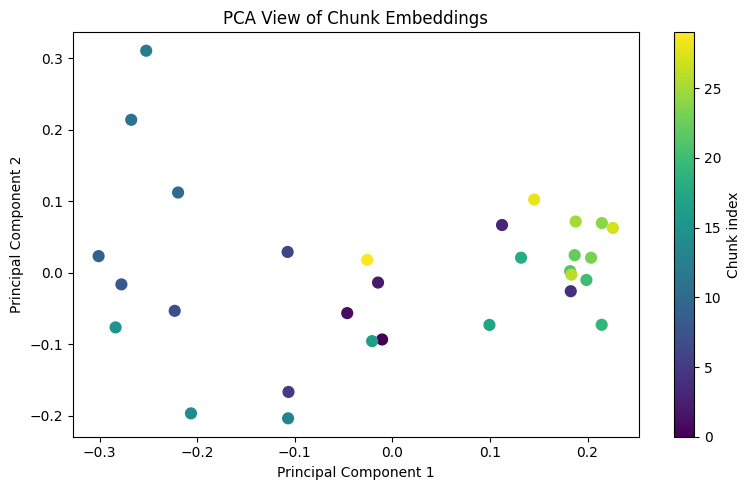

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# A small sample is enough here. The goal is to see how chunk embeddings spread out.
sample_chunks = chunks[: min(30, len(chunks))]
sample_texts = [doc.page_content for doc in sample_chunks]

if len(sample_texts) < 2:
    print("Need at least 2 chunks to plot a 2D PCA view of the embeddings.")
else:
    sample_vectors = np.array(embeddings.embed_documents(sample_texts))
    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(sample_vectors)

    plt.figure(figsize=(8, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=range(len(coordinates)), cmap="viridis", s=60)
    plt.title("PCA View of Chunk Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Chunk index")
    plt.tight_layout()
    plt.show()


## Add a New Agent

This agent focuses only on recent developments and uses Tavily as its main tool.


In [ ]:
trend_analyst = Agent(
    role="Trend Analyst",
    goal="Summarize the latest news and trends on a given AI topic.",
    backstory=(
        "You track current developments, keep the summary focused, "
        "and highlight the most relevant changes rather than dumping raw search output."
    ),
    tools=[search_web],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

trend_task = Task(
    description=(
        "Search the web and summarize the latest news on: AI agents in healthcare\n"
        "Return 5 short bullet points with the main takeaway from each."
    ),
    expected_output="Five concise bullet points covering the latest trend updates.",
    agent=trend_analyst,
)

trend_crew = Crew(agents=[trend_analyst], tasks=[trend_task], process=Process.sequential, verbose=True)
trend_summary = trend_crew.kickoff()
print(trend_summary)


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: c0279bd3-b733-4471-a98c-e9638225f1fa                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│  ID: 68c7aa2c-8d53-45dd-a13d-e4826a5d1e53                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Trend Analyst                                                                                           │
│                                                                                                                 │
│  Task: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: search_web                                                                                               │
│  Args: {'question': 'AI agents in healthcare latest news and trends'}                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool search_web executed with result: [1] Health care leans into agentic AI | Deloitte Insights
URL: https://www.deloitte.com/us/en/insights/industry/health-care/agentic-ai-health-care-operating-model-change.html
Content: Fierce Healthcar...


...

[CrewAIEventsBus] Warning: Event pairing mismatch. 'task_completed' closed 'agent_execution_started' (expected 
'task_started')

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│  Agent: Trend Analyst                                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[CrewAIEventsBus] Warning: Event pairing mismatch. 'crew_kickoff_completed' closed 'task_started' (expected 
'crew_kickoff_started')

- Health care organizations are increasingly investing in agentic AI, with leaders easing adoption hurdles and aiming to scale beyond pilots. 
- AI agents are being used in healthcare for tasks such as handling patient phone calls, capturing clinical requests, and automating documentation.
- AstraZeneca acquired Modella AI to integrate AI-driven pathology and biomarker discovery into its research organization to enhance oncology clinical trials.
- McCrae Tech launched "Orchestral," a health-native AI orchestrator designed to unify healthcare data sources and connect them with governed AI agents and workflows.
- AI agents in healthcare are being utilized for various tasks, including automating back-office work, virtual nursing, and improving patient access.


╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: c0279bd3-b733-4471-a98c-e9638225f1fa                                                                       │
│  Final Output: - Health care organizations are increasingly investing in agentic AI, with leaders easing        │
│  adoption hurdles and aiming to scale beyond pilots.                                                            │
│  - AI agents are being used in healthcare for tasks such as handling patient phone calls, capturing clinical    │
│  requests, and automating documentation.                                                                        │
│  - AstraZeneca acquired Modella AI to integrate AI-driven pathology and biomarker discovery into its research   │
│  organization to enhance oncology clinical trials.                                                              │
│  - McCrae Tech launched "Orchestral," a health-native AI orchestrator designed to unify healthcare data         │
│  sources and connect them with governed AI agents and workflows.                                                │
│  - AI agents in healthcare are being utilized for various tasks, including automating back-office work,         │
│  virtual nursing, and improving patient access.                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Report Generator Agent

This part creates a markdown report and saves it in the `reports/` folder.


In [ ]:
report_generator = Agent(
    role="Report Generator",
    goal="Create a structured markdown report grounded in both local documents and live web findings.",
    backstory=(
        "You write practical research reports. You keep the structure sharp, "
        "call out limitations honestly, and make the report useful to a reader who wants the big picture quickly."
    ),
    tools=[],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

report_task = Task(
    description=(
        "Write a markdown report on: AI in clinical summarization\n\n"
        "Include these sections exactly:\n"
        "1. Executive Summary\n"
        "2. Key Findings\n"
        "3. Challenges and Limitations\n"
        "4. Future Outlook\n"
        "5. Conclusion\n"
        "6. Sources\n\n"
        "Use the knowledge base and web search where appropriate."
    ),
    expected_output="A complete markdown report with the requested sections.",
    agent=report_generator,
)

report_crew = Crew(agents=[report_generator], tasks=[report_task], process=Process.sequential, verbose=True)
report_output = report_crew.kickoff()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path = REPORTS_DIR / f"report_{timestamp}.md"
report_path.write_text(str(report_output), encoding="utf-8")

print(f"Saved report to {report_path}")
print(str(report_output)[:1200])


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: a49ae337-2a09-455c-a054-3c78009ffb8a                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│  ID: 3bb02adc-8eaa-4723-9626-38a30259c903                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Task: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # AI in Clinical Summarization: A Review of Current Developments and Future Directions                         │
│  ## 1. Executive Summary                                                                                        │
│                                                                                                                 │
│  Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in       │
│  healthcare that involves condensing large volumes of patient data into concise, clinically relevant            │
│  summaries. This report provides an overview of the current state of AI in clinical summarization,              │
│  highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI     │
│  has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several      │
│  challenges must be addressed to fully realize its benefits.                                                    │
│                                                                                                                 │
│  ## 2. Key Findings                                                                                             │
│                                                                                                                 │
│  * **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational             │
│  technologies driving AI applications in clinical summarization. These technologies enable the extraction of    │
│  relevant information from unstructured clinical text and the generation of summaries.                          │
│  * **Improved Efficiency and Accuracy**: Studies have shown that AI can significantly reduce the time           │
│  healthcare professionals spend on summarization tasks while improving the accuracy and consistency of          │
│  summaries.                                                                                                     │
│  * **Integration with Electronic Health Records (EHRs)**: AI-powered clinical summarization tools are being     │
│  integrated with EHR systems, enhancing their functionality and facilitating the seamless generation of         │
│  clinical summaries.                                                                                            │
│  * **Variability in Data Quality**: The effectiveness of AI in clinical summarization is heavily dependent on   │
│  the quality of the input data. High variability in data quality can significantly impact the performance of    │
│  AI models.                                                                                                     │
│                                                                                                                 │
│  ## 3. Challenges and Limitations                                                                               │
│                                                                                                                 │
│  * **Data Privacy and Security**: The use of AI in clinical summarization raises significant concerns           │
│  regarding data privacy and security. Ensuring the confidentiality, integrity, and availability of patient      │
│  data is paramount.                                    

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Saved report to /content/reports/report_20260331_000534.md
# AI in Clinical Summarization: A Review of Current Developments and Future Directions
## 1. Executive Summary

Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in healthcare that involves condensing large volumes of patient data into concise, clinically relevant summaries. This report provides an overview of the current state of AI in clinical summarization, highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several challenges must be addressed to fully realize its benefits.

## 2. Key Findings

* **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational technologies driving AI applications in clinical summarization. These technologies enable the extraction of relevant information from

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: a49ae337-2a09-455c-a054-3c78009ffb8a                                                                       │
│  Final Output: # AI in Clinical Summarization: A Review of Current Developments and Future Directions           │
│  ## 1. Executive Summary                                                                                        │
│                                                                                                                 │
│  Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in       │
│  healthcare that involves condensing large volumes of patient data into concise, clinically relevant            │
│  summaries. This report provides an overview of the current state of AI in clinical summarization,              │
│  highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI     │
│  has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several      │
│  challenges must be addressed to fully realize its benefits.                                                    │
│                                                                                                                 │
│  ## 2. Key Findings                                                                                             │
│                                                                                                                 │
│  * **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational             │
│  technologies driving AI applications in clinical summarization. These technologies enable the extraction of    │
│  relevant information from unstructured clinical text and the generation of summaries.                          │
│  * **Improved Efficiency and Accuracy**: Studies have shown that AI can significantly reduce the time           │
│  healthcare professionals spend on summarization tasks while improving the accuracy and consistency of          │
│  summaries.                                                                                                     │
│  * **Integration with Electronic Health Records (EHRs)**: AI-powered clinical summarization tools are being     │
│  integrated with EHR systems, enhancing their functionality and facilitating the seamless generation of         │
│  clinical summaries.                                                                                            │
│  * **Variability in Data Quality**: The effectiveness of AI in clinical summarization is heavily dependent on   │
│  the quality of the input data. High variability in data quality can significantly impact the performance of    │
│  AI models.                                                                                                     │
│                                                                                                                 │
│  ## 3. Challenges and Limitations                                                                               │
│                                                                                                                 │
│  * **Data Privacy and Security**: The use of AI in clinical summarization raises significant concerns           │
│  regarding data privacy and security. Ensuring the confidentiality, integrity, and availability of patient      │
│  data is paramount.                                   

## Interactive Question Loop

Run this only when you want to keep asking questions in one session.


In [ ]:
def ask_with_agents(question: str):
    crew = build_qa_crew(question)
    return crew.kickoff()


print("Ask a question about your local documents or a current topic. Leave it blank to stop.\n")

while True:
    user_question = input("Question: ").strip()
    if not user_question:
        print("Session ended.")
        break

    print("\nAnswer:\n")
    print(ask_with_agents(user_question))
    print("\n" + "-" * 80 + "\n")


Ask a question about your local documents or a current topic. Leave it blank to stop.

Question: In the Radiology and Biomedical Case Reports section of the provided document, what percentage were the original case reports reduce by, when using BARTcnn and GPT3 davinci?

Answer:



╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 1458d64f-a638-4072-9c80-e30d3b629598                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the following question: In the Radiology and Biomedical Case Reports section of the provided    │
│  document, what percentage were the original case reports reduce by, when using BARTcnn and GPT3 davinci?       │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  ID: 4c865e8f-e6ff-4869-ab09-81f8ca98f047                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Task: Research the following question: In the Radiology and Biomedical Case Reports section of the provided    │
│  document, what percentage were the original case reports reduce by, when using BARTcnn and GPT3 davinci?       │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ## Research Notes                                                                                              │
│                                                                                                                 │
│  ### Question                                                                                                   │
│  In the Radiology and Biomedical Case Reports section of the provided document, what percentage were the        │
│  original case reports reduced by, when using BARTcnn and GPT3 davinci?                                         │
│                                                                                                                 │
│  ### Findings                                                                                                   │
│  The provided document indicates that the AI models, especially BARTcnn and GPT3 davinci, demonstrated          │
│  considerable summarization capabilities, enhancing the readability and comprehensiveness of summaries, while   │
│  simultaneously reducing text length to less than 20% of the original case reports.                             │
│                                                                                                                 │
│  ### Source Labels                                                                                              │
│  - **doc.pdf (page 4)**: This page discusses the use of various NLP summarization models, including BARTcnn     │
│  and GPT3 davinci, for summarizing neuro-radiology case reports and charts. It mentions that these models       │
│  reduced the text length to less than 20% of the original case reports.                                         │
│                                                                                                                 │
│  ### Conclusion                                                                                                 │
│  The original case reports were reduced by more than 80% when using BARTcnn and GPT3 davinci, as they reduced   │
│  the text length to less than 20% of the original case reports.                                                 │
│                                                                                                                 │
│  ### Final Answer                                                                                               │
│  The original case reports in the Radiology and Biomedical Case Reports section were reduced to less than 20%   │
│  of their original length when using BARTcnn and GPT3 davinci. This implies a reduction of more than 80% in     │
│  the original case reports.                                                                                     │
│                                                                                                                 │
│  ## Structured Research Notes                                                                                   │
│                                                                                                                 │
│  1. **Reduction Percentage**: The original case reports were reduced to less than 20% of their original         │
│  length.                                                                                                        │
│  2. **Models Used**: BARTcnn and GPT3 davinci.         

...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the draft answer for this question: What are the medical errors associated with patient chart     │
│  review ?                                                                                                       │
│                                                                                                                 │
│  Check factual grounding, clarity, and completeness. Return the improved final answer, followed by a short      │
│  'Sources' section.                                                                                             │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Medical Errors Associated with Patient Chart Review

The medical errors associated with patient chart review are a significant concern in healthcare, as they can have serious consequences for patient care and outcomes. According to the research notes, these errors include:

1. **Diagnostic and Management Errors**: Even with thorough chart reviews, errors can occur. A study found that 36.6% of cases had to be corrected in either pathophysiological process identification or therapy/management decisions, despite taking 30 minutes per patient for chart review. This highlights the imperfection of even the most thorough patient chart review process.

2. **Iatrogenic Adverse Drug Events (ADEs)**: These are often caused by inconsistencies in a clinician's knowledge of patient allergies to medications. Insufficient documentation, poor patient health record communication, and lack of proper information collection from charts can lead to ADEs. For instance, a common case of medical error are i

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 76fb3722-6e6e-4f95-8d79-a46d25fa7ebf                                                                       │
│  Final Output: ## Medical Errors Associated with Patient Chart Review                                           │
│                                                                                                                 │
│  The medical errors associated with patient chart review are a significant concern in healthcare, as they can   │
│  have serious consequences for patient care and outcomes. According to the research notes, these errors         │
│  include:                                                                                                       │
│                                                                                                                 │
│  1. **Diagnostic and Management Errors**: Even with thorough chart reviews, errors can occur. A study found     │
│  that 36.6% of cases had to be corrected in either pathophysiological process identification or                 │
│  therapy/management decisions, despite taking 30 minutes per patient for chart review. This highlights the      │
│  imperfection of even the most thorough patient chart review process.                                           │
│                                                                                                                 │
│  2. **Iatrogenic Adverse Drug Events (ADEs)**: These are often caused by inconsistencies in a clinician's       │
│  knowledge of patient allergies to medications. Insufficient documentation, poor patient health record          │
│  communication, and lack of proper information collection from charts can lead to ADEs. For instance, a common  │
│  case of medical error are iatrogenic adverse drug events (ADE), most commonly caused by inconsistencies in a   │
│  clinician’s knowledge on patient allergies to medications.                                                     │
│                                                                                                                 │
│  3. **Insufficient Clinician Knowledge**: Incomplete record review and internal inconsistencies in health       │
│  records can lead to medical errors. A study highlighted that 29% of preventable ADEs were caused by a lack of  │
│  clinician knowledge despite sufficiently documented patient information. This emphasizes the importance of     │
│  accurate and thorough chart reviews to prevent such errors.                                                    │
│                                                                                                                 │
│  4. **Transition of Care Errors**: Errors can occur when patients are transferred between clinicians,           │
│  highlighting the importance of accurate and thorough chart reviews during transitions. This is a critical      │
│  aspect of patient care, as it ensures that patients receive continuous and high-quality care.                  │
│                                                                                                                 │
│  ## Detailed Explanation                                                                                        │
│                                                                                                                 │
│  The medical errors associated with patient chart review can have serious consequences for patient care and     │
│  outcomes. For example, diagnostic and management erro

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Question: 
Session ended.


In [ ]:
#  sample question1: In the Radiology and Biomedical Case Reports section of the provided document, what percentage were the original case reports reduce by, when using BARTcnn and GPT3 davinci?
#  sample question2: What are the medical errors associated with patient chart review ?